In [1]:
import zipfile
import os
import pandas as pd

# Define the path to the zip file and the extraction directory
zip_file_path = '/content/archive (3).zip'
extract_dir = '/content/dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")


'/content/archive (3).zip' unzipped to '/content/dataset'


In [2]:
# List the contents of the extracted directory to find the CSV file
print("Contents of the extracted directory:")
print(os.listdir(extract_dir))

# Assuming there is a CSV file directly in the extracted directory, let's find it.
# You might need to adjust this if the CSV is in a subfolder or has a different name.
csv_files = [f for f in os.listdir(extract_dir) if f.endswith('.csv')]

if csv_files:
    data_file_path = os.path.join(extract_dir, csv_files[0])
    print(f"\nLoading data from: {data_file_path}")
    df = pd.read_csv(data_file_path)
    print("Data loaded successfully!")
else:
    print("No CSV files found in the extracted directory.")
    df = pd.DataFrame() # Create an empty DataFrame if no CSV is found


Contents of the extracted directory:
['business.csv', 'economy.csv', 'Clean_Dataset.csv']

Loading data from: /content/dataset/business.csv
Data loaded successfully!


## Initial Data Exploration (EDA)

Let's start by examining the first few rows, checking the data types, and looking at some basic descriptive statistics.

In [3]:
if not df.empty:
    print("### First 5 rows of the dataset:")
    display(df.head())

    print("\n### Dataset Info (data types and non-null counts):")
    df.info()

    print("\n### Descriptive Statistics:")
    display(df.describe())
else:
    print("DataFrame is empty, cannot perform EDA.")


### First 5 rows of the dataset:


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"



### Dataset Info (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB

### Descriptive Statistics:


,num_code
count,93487.000000
mean,780.056147
std,147.616038
min,401.000000
25%,706.000000
50%,820.000000
75%,874.000000
max,996.000000


## Data Cleaning and Type Conversion

Based on the `df.info()` output, several columns need cleaning and type conversion:
- **`price`**: Currently an object due to commas. Needs to be converted to integer.
- **`time_taken`**: Object type, but represents duration. Needs to be converted to a numerical representation (e.g., total minutes).
- **`stop`**: Object type, contains newline characters and 'non-stop' string. Needs cleaning for consistent categorical representation.
- **`date`**, **`dep_time`**, **`arr_time`**: Can be converted to datetime objects for better time-based analysis.

In [4]:
# 1. Clean and convert 'price' column to numeric
if 'price' in df.columns:
    df['price'] = df['price'].str.replace(',', '').astype(int)
    print("Updated 'price' column to integer type.")
else:
    print("'price' column not found.")

# 2. Clean and convert 'time_taken' to total minutes (integer)
def convert_time_taken_to_minutes(time_str):
    if pd.isna(time_str): # Handle potential NaN values
        return None
    parts = time_str.replace('h', '').replace('m', '').split()
    total_minutes = 0
    if len(parts) == 2:
        total_minutes = int(parts[0]) * 60 + int(parts[1])
    elif len(parts) == 1:
        if 'h' in time_str:
            total_minutes = int(parts[0]) * 60
        elif 'm' in time_str:
            total_minutes = int(parts[0])
    return total_minutes

if 'time_taken' in df.columns:
    df['time_taken_minutes'] = df['time_taken'].apply(convert_time_taken_to_minutes)
    print("Created 'time_taken_minutes' column and converted 'time_taken' to total minutes.")
else:
    print("'time_taken' column not found.")

# 3. Clean 'stop' column
if 'stop' in df.columns:
    # Remove newline, tab, and extra spaces, then strip leading/trailing spaces
    df['stop'] = df['stop'].str.replace(r'\n|\t', '', regex=True).str.strip()
    print("Cleaned 'stop' column.")
else:
    print("'stop' column not found.")

# 4. Convert 'date', 'dep_time', 'arr_time' to datetime objects
# For 'date':
if 'date' in df.columns:
    # Assuming date format is DD-MM-YYYY
    df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
    print("Converted 'date' column to datetime.")
else:
    print("'date' column not found.")

# For 'dep_time' and 'arr_time':
# These are typically just time, but pandas to_datetime needs a full date.
# We can convert them to time objects if needed, or leave as string if only time part is used.
# For now, let's just make sure they are clean strings.
print("\nUpdated DataFrame Info after cleaning and conversions:")
df.info()

print("\nFirst 5 rows with updated columns:")
display(df.head())

Updated 'price' column to integer type.
Created 'time_taken_minutes' column and converted 'time_taken' to total minutes.
Cleaned 'stop' column.
Converted 'date' column to datetime.

Updated DataFrame Info after cleaning and conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                93487 non-null  datetime64[ns]
 1   airline             93487 non-null  object        
 2   ch_code             93487 non-null  object        
 3   num_code            93487 non-null  int64         
 4   dep_time            93487 non-null  object        
 5   from                93487 non-null  object        
 6   time_taken          93487 non-null  object        
 7   stop                93487 non-null  object        
 8   arr_time            93487 non-null  object        
 9   to                  93487 non-nul

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,time_taken_minutes
0,2022-02-11,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,25612,120
1,2022-02-11,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,25612,135
2,2022-02-11,Air India,AI,531,20:00,Delhi,24h 45m,1-stop,20:45,Mumbai,42220,1485
3,2022-02-11,Air India,AI,839,21:25,Delhi,26h 30m,1-stop,23:55,Mumbai,44450,1590
4,2022-02-11,Air India,AI,544,17:15,Delhi,06h 40m,1-stop,23:55,Mumbai,46690,400


## Further Exploratory Data Analysis (EDA)

Let's visualize the distributions of key variables and explore relationships.

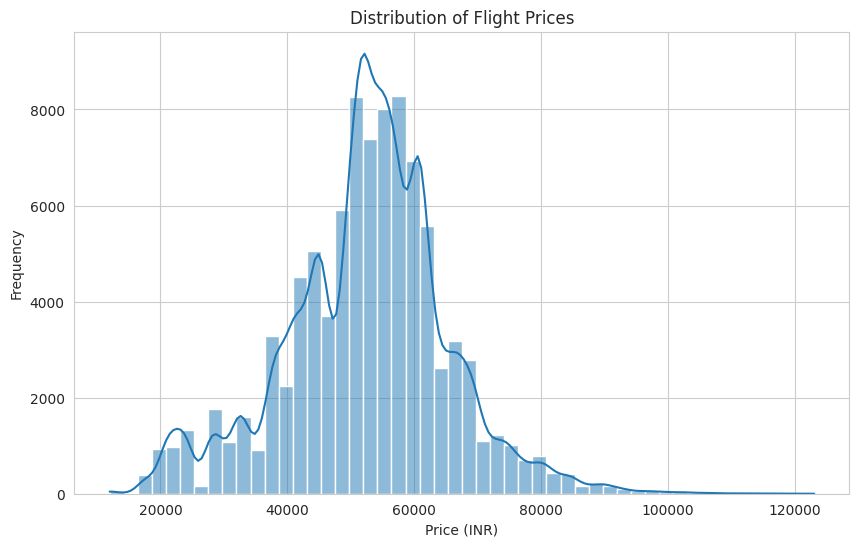

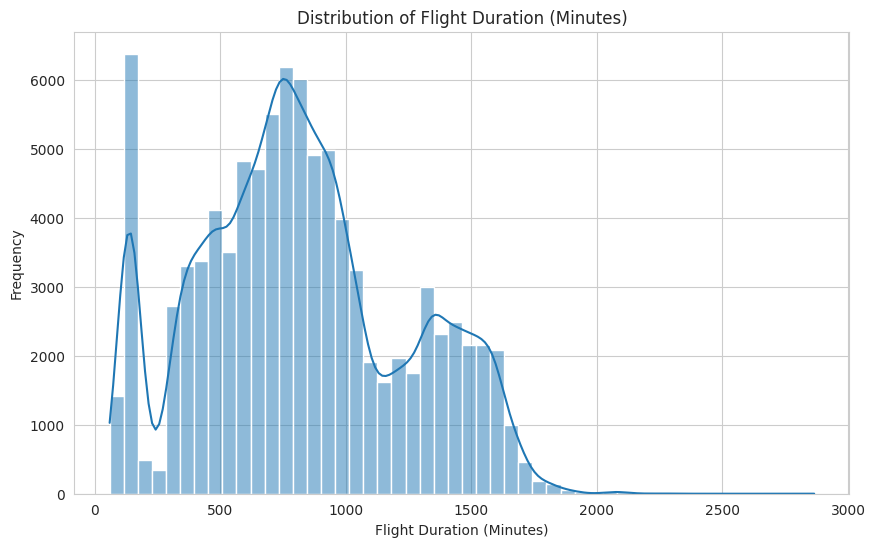

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# 1. Distribution of 'price'
if 'price' in df.columns and not df['price'].empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], bins=50, kde=True)
    plt.title('Distribution of Flight Prices')
    plt.xlabel('Price (INR)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("'price' column not available or empty for plotting.")

# 2. Distribution of 'time_taken_minutes'
if 'time_taken_minutes' in df.columns and not df['time_taken_minutes'].empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['time_taken_minutes'], bins=50, kde=True)
    plt.title('Distribution of Flight Duration (Minutes)')
    plt.xlabel('Flight Duration (Minutes)')
    plt.ylabel('Frequency')
    plt.show()
else:
    print("'time_taken_minutes' column not available or empty for plotting.")


### Categorical Feature Distributions

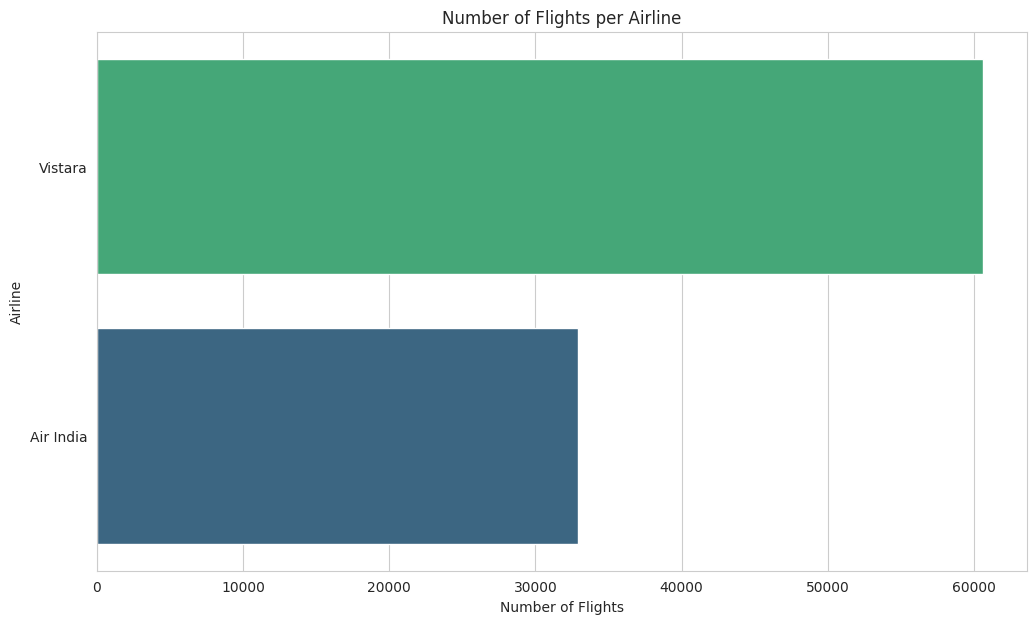

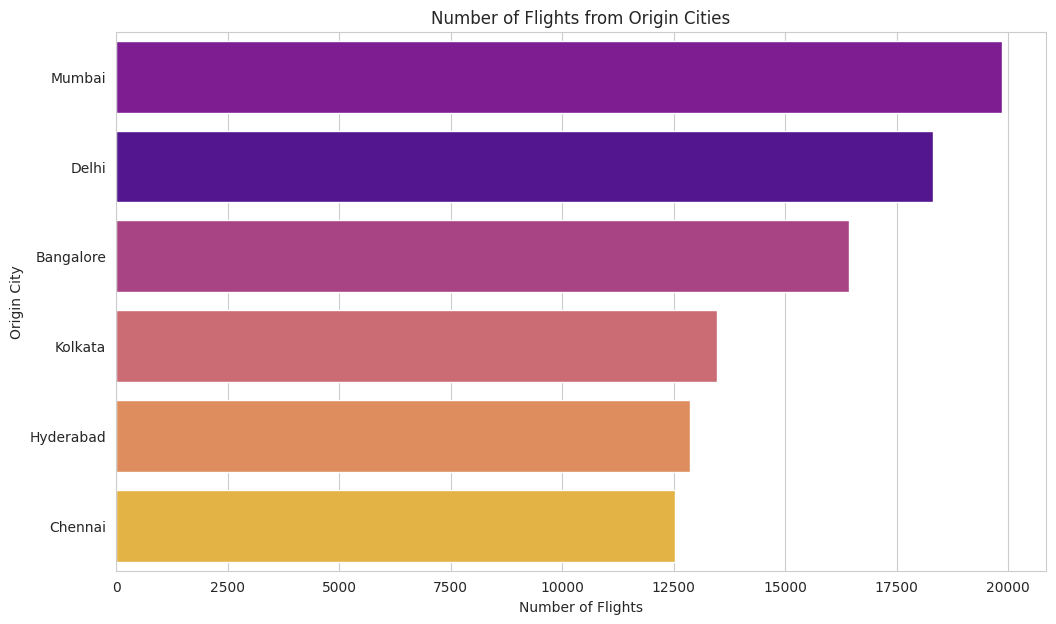

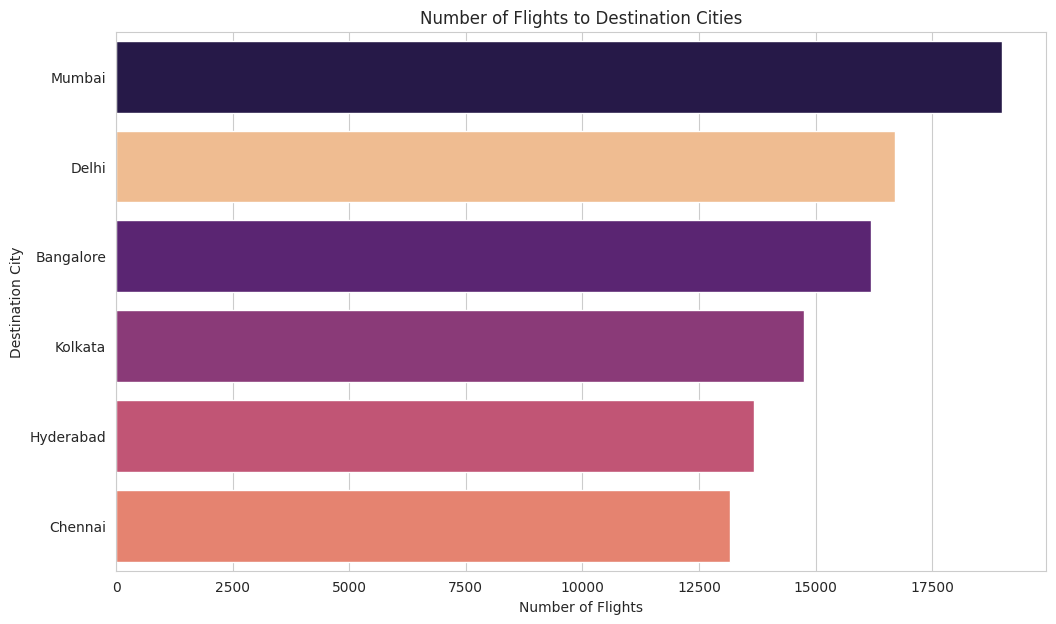

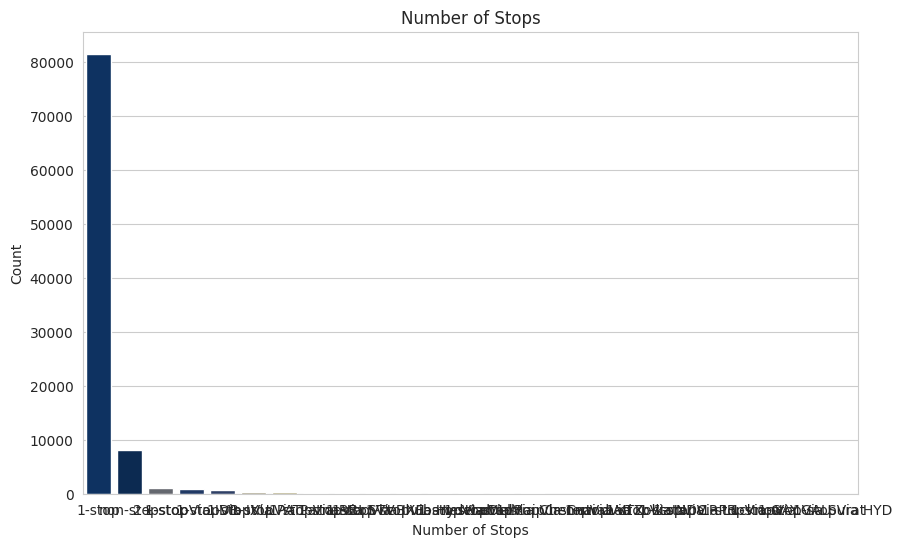

In [12]:
# 3. Distribution of 'airline'
if 'airline' in df.columns and not df['airline'].empty:
    plt.figure(figsize=(12, 7))
    sns.countplot(y='airline', data=df, order=df['airline'].value_counts().index, palette='viridis', hue='airline', legend=False)
    plt.title('Number of Flights per Airline')
    plt.xlabel('Number of Flights')
    plt.ylabel('Airline')
    plt.show()
else:
    print("'airline' column not available or empty for plotting.")

# 4. Distribution of 'from' (Origin Cities)
if 'from' in df.columns and not df['from'].empty:
    plt.figure(figsize=(12, 7))
    sns.countplot(y='from', data=df, order=df['from'].value_counts().index, palette='plasma', hue='from', legend=False)
    plt.title('Number of Flights from Origin Cities')
    plt.xlabel('Number of Flights')
    plt.ylabel('Origin City')
    plt.show()
else:
    print("'from' column not available or empty for plotting.")

# 5. Distribution of 'to' (Destination Cities)
if 'to' in df.columns and not df['to'].empty:
    plt.figure(figsize=(12, 7))
    sns.countplot(y='to', data=df, order=df['to'].value_counts().index, palette='magma', hue='to', legend=False)
    plt.title('Number of Flights to Destination Cities')
    plt.xlabel('Number of Flights')
    plt.ylabel('Destination City')
    plt.show()
else:
    print("'to' column not available or empty for plotting.")

# 6. Distribution of 'stop'
if 'stop' in df.columns and not df['stop'].empty:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='stop', data=df, order=df['stop'].value_counts().index, palette='cividis', hue='stop', legend=False)
    plt.title('Number of Stops')
    plt.xlabel('Number of Stops')
    plt.ylabel('Count')
    plt.show()
else:
    print("'stop' column not available or empty for plotting.")

## Exploring Relationships Between Variables

Let's visualize how `price` and `time_taken_minutes` relate to other categorical features.

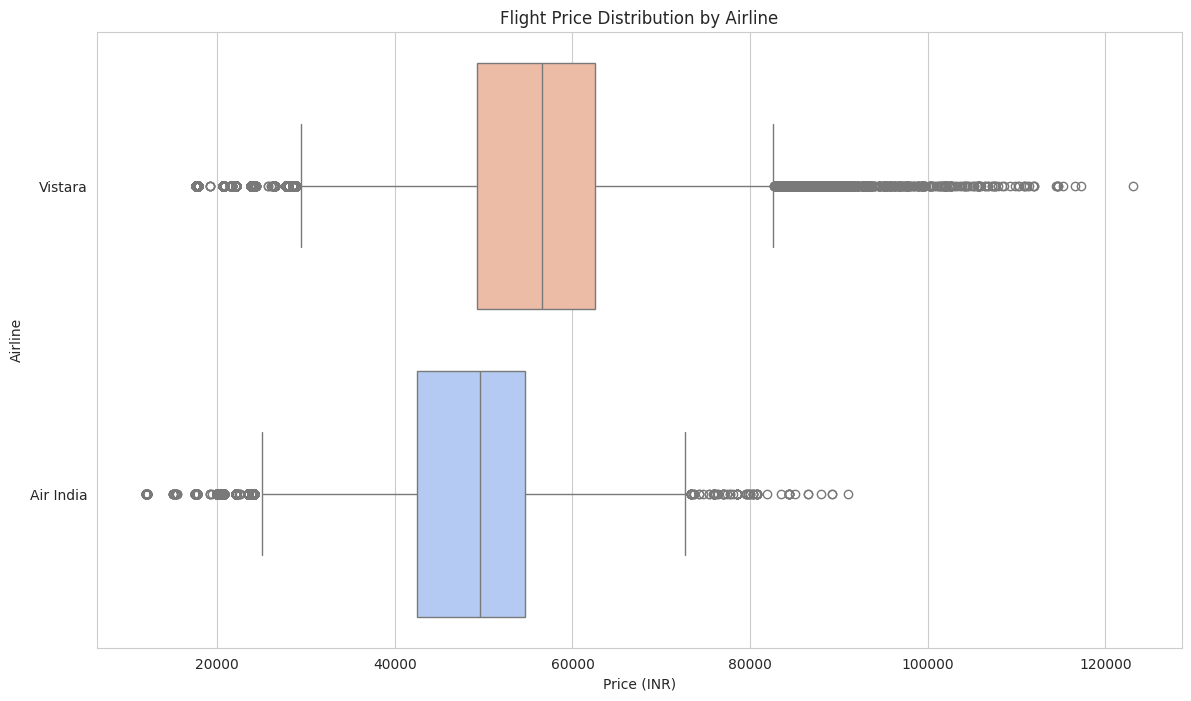

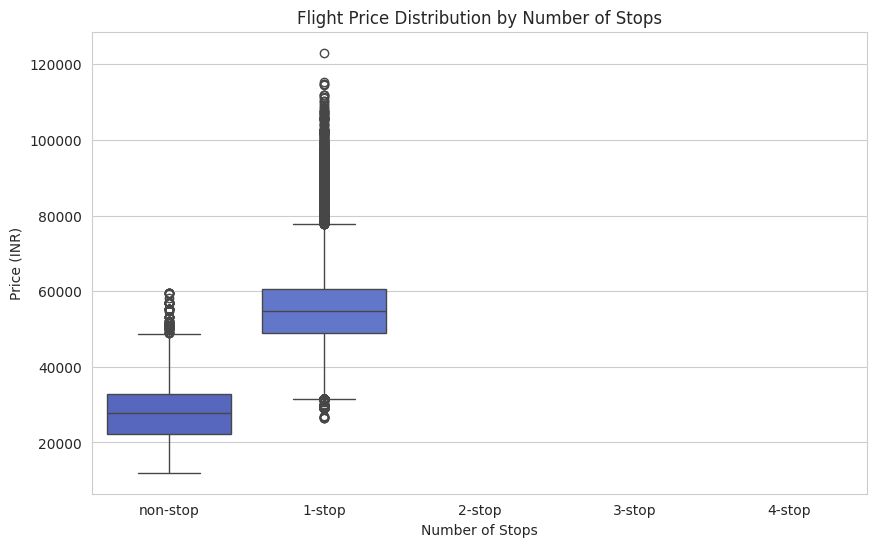

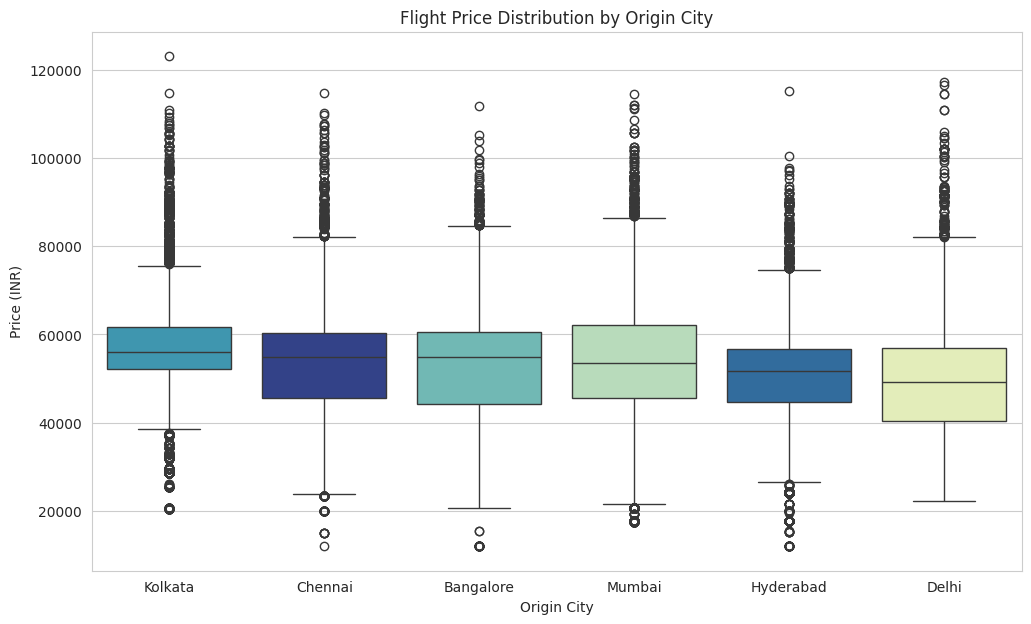

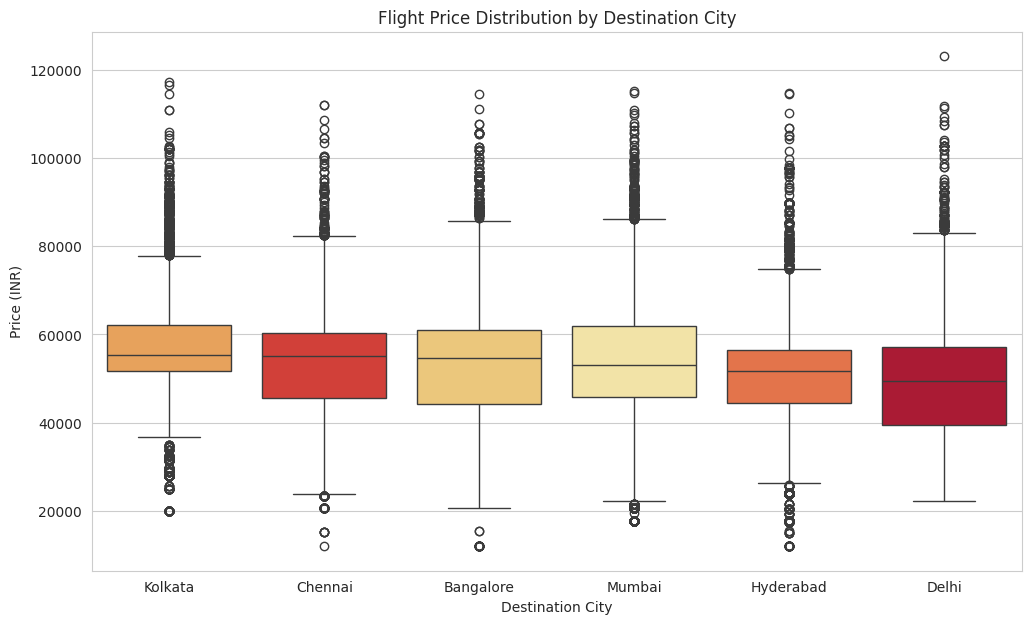

In [13]:
# Relationship between 'airline' and 'price'
if 'airline' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(14, 8))
    sns.boxplot(y='airline', x='price', data=df, order=df.groupby('airline')['price'].median().sort_values(ascending=False).index, palette='coolwarm', hue='airline', legend=False)
    plt.title('Flight Price Distribution by Airline')
    plt.xlabel('Price (INR)')
    plt.ylabel('Airline')
    plt.show()
else:
    print("'airline' or 'price' column not available for plotting.")

# Relationship between 'stop' and 'price'
if 'stop' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='stop', y='price', data=df, order=['non-stop', '1-stop', '2-stop', '3-stop', '4-stop'], palette='coolwarm', hue='stop', legend=False)
    plt.title('Flight Price Distribution by Number of Stops')
    plt.xlabel('Number of Stops')
    plt.ylabel('Price (INR)')
    plt.show()
else:
    print("'stop' or 'price' column not available for plotting.")

# Relationship between 'from' and 'price'
if 'from' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='from', y='price', data=df, order=df.groupby('from')['price'].median().sort_values(ascending=False).index, palette='YlGnBu', hue='from', legend=False)
    plt.title('Flight Price Distribution by Origin City')
    plt.xlabel('Origin City')
    plt.ylabel('Price (INR)')
    plt.show()
else:
    print("'from' or 'price' column not available for plotting.")

# Relationship between 'to' and 'price'
if 'to' in df.columns and 'price' in df.columns:
    plt.figure(figsize=(12, 7))
    sns.boxplot(x='to', y='price', data=df, order=df.groupby('to')['price'].median().sort_values(ascending=False).index, palette='YlOrRd', hue='to', legend=False)
    plt.title('Flight Price Distribution by Destination City')
    plt.xlabel('Destination City')
    plt.ylabel('Price (INR)')
    plt.show()
else:
    print("'to' or 'price' column not available for plotting.")

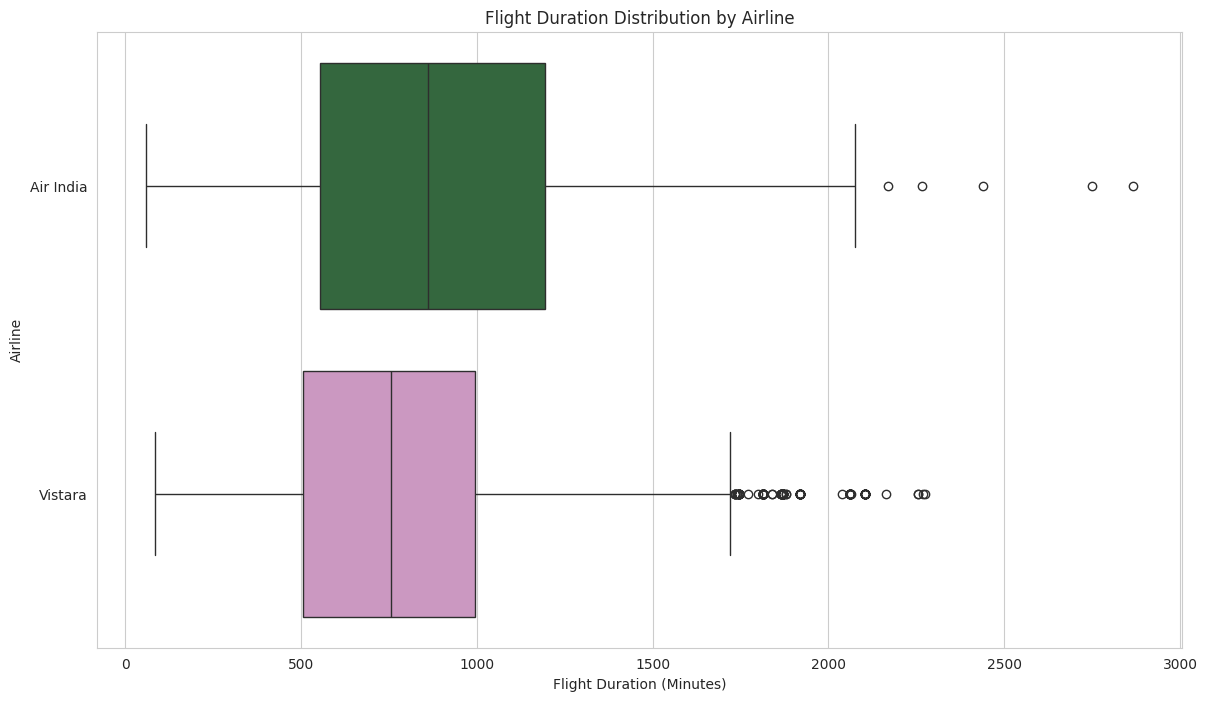

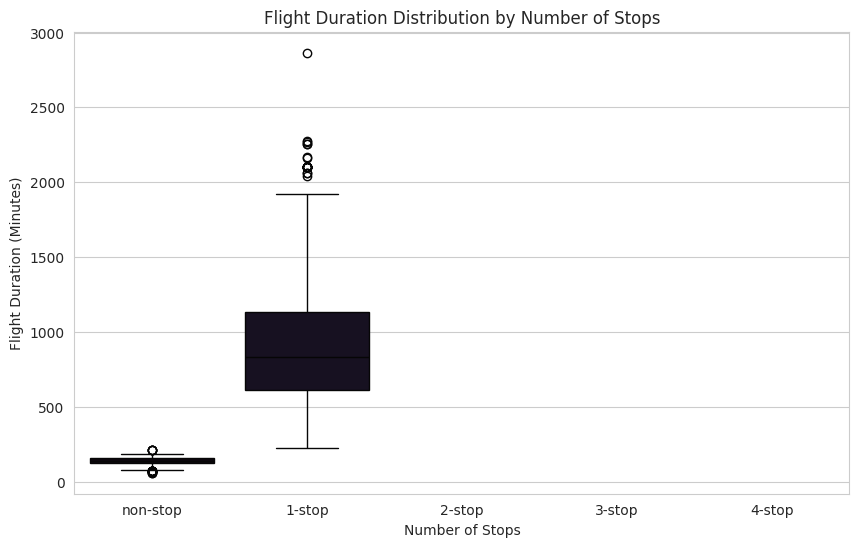

In [14]:
# Relationship between 'airline' and 'time_taken_minutes'
if 'airline' in df.columns and 'time_taken_minutes' in df.columns:
    plt.figure(figsize=(14, 8))
    sns.boxplot(y='airline', x='time_taken_minutes', data=df, order=df.groupby('airline')['time_taken_minutes'].median().sort_values(ascending=False).index, palette='cubehelix', hue='airline', legend=False)
    plt.title('Flight Duration Distribution by Airline')
    plt.xlabel('Flight Duration (Minutes)')
    plt.ylabel('Airline')
    plt.show()
else:
    print("'airline' or 'time_taken_minutes' column not available for plotting.")

# Relationship between 'stop' and 'time_taken_minutes'
if 'stop' in df.columns and 'time_taken_minutes' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='stop', y='time_taken_minutes', data=df, order=['non-stop', '1-stop', '2-stop', '3-stop', '4-stop'], palette='cubehelix', hue='stop', legend=False)
    plt.title('Flight Duration Distribution by Number of Stops')
    plt.xlabel('Number of Stops')
    plt.ylabel('Flight Duration (Minutes)')
    plt.show()
else:
    print("'stop' or 'time_taken_minutes' column not available for plotting.")

## Detailed Analysis Tasks

Now we will address the specific questions requested:
1. Highest average ticket price per airline.
2. Price vs. Days Left before departure.
3. Top 5 most expensive travel routes.
4. Impact of Number of Stops on price.
5. Comparison of Economy vs. Business class prices.

In [15]:
# Load both datasets to compare Business and Economy
business_df = pd.read_csv('/content/dataset/business.csv')
economy_df = pd.read_csv('/content/dataset/economy.csv')

# Clean 'price' for both
business_df['price'] = business_df['price'].str.replace(',', '').astype(int)
economy_df['price'] = economy_df['price'].str.replace(',', '').astype(int)

# Add a 'class' column
business_df['class'] = 'Business'
economy_df['class'] = 'Economy'

# Combine datasets for full analysis
full_df = pd.concat([business_df, economy_df], ignore_index=True)

# Clean 'stop' for the combined dataset
full_df['stop'] = full_df['stop'].str.replace(r'\n|\t', '', regex=True).str.strip()

print("Combined dataset created with", full_df.shape[0], "rows.")

Combined dataset created with 300261 rows.


Average Ticket Price per Airline:
airline
Vistara      30396.536302
Air India    23506.647217
SpiceJet      6179.278881
GO FIRST      5651.930578
Indigo        5324.216303
StarAir       4932.655738
AirAsia       4091.072742
Trujet        3244.634146
Name: price, dtype: float64


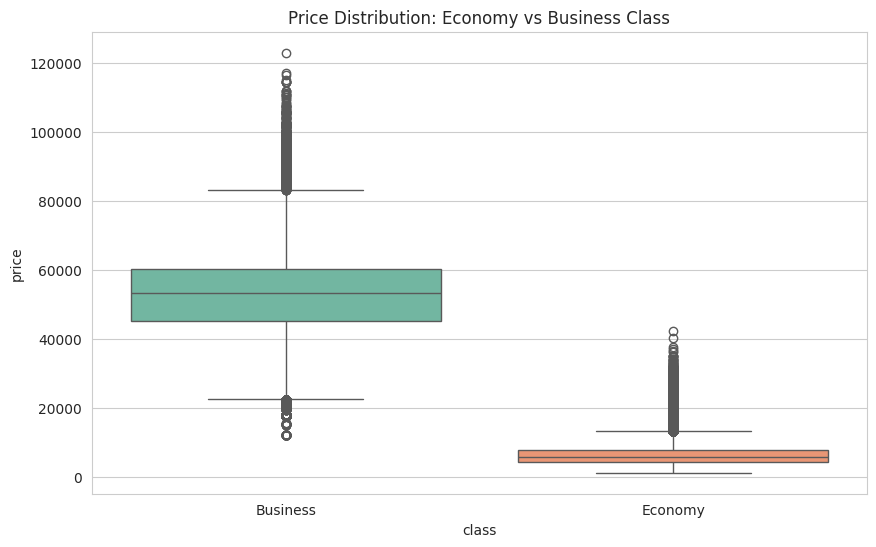

In [16]:
# 1. Airline with highest average ticket price
avg_price_airline = full_df.groupby('airline')['price'].mean().sort_values(ascending=False)
print("Average Ticket Price per Airline:")
print(avg_price_airline)

# 5. Compare Economy vs Business distributions
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='price', data=full_df, palette='Set2', hue='class', legend=False)
plt.title('Price Distribution: Economy vs Business Class')
plt.show()

Top 5 Most Expensive Travel Routes (Average Price):
route
Chennai to Bangalore    25081.850454
Kolkata to Chennai      23660.361040
Bangalore to Kolkata    23498.234221
Bangalore to Chennai    23321.850078
Mumbai to Bangalore     23147.873807
Name: price, dtype: float64


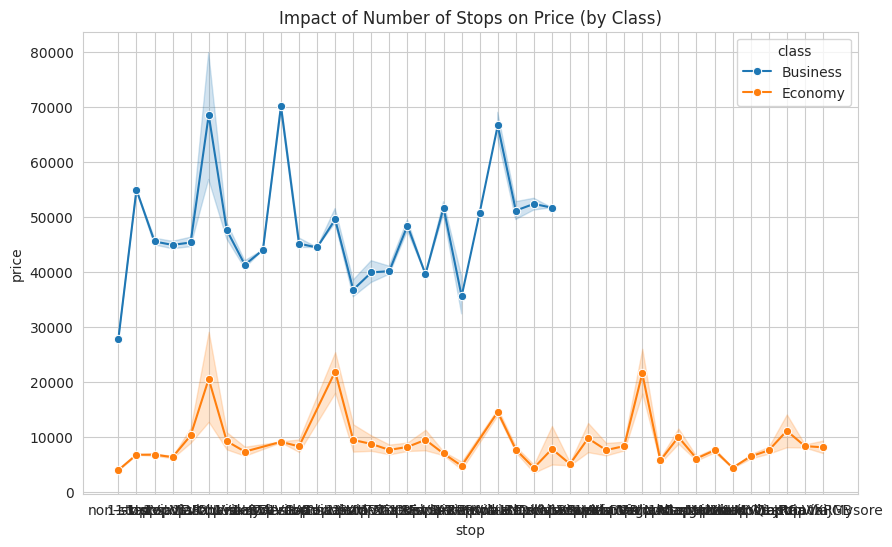

In [17]:
# 3. Top 5 most expensive travel routes
full_df['route'] = full_df['from'] + ' to ' + full_df['to']
top_routes = full_df.groupby('route')['price'].mean().sort_values(ascending=False).head(5)

print("Top 5 Most Expensive Travel Routes (Average Price):")
print(top_routes)

# 4. Investigate Stops vs Price
plt.figure(figsize=(10, 6))
sns.lineplot(x='stop', y='price', hue='class', data=full_df, marker='o')
plt.title('Impact of Number of Stops on Price (by Class)')
plt.show()

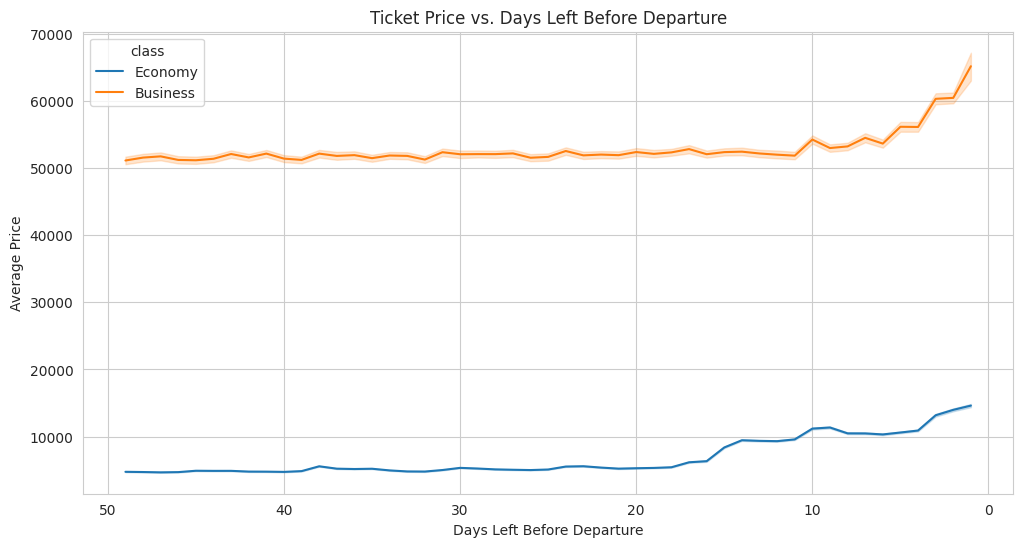

In [19]:
# 2. Analyze how 'days_left' influences ticket price
# We'll use Clean_Dataset.csv as it already contains the pre-calculated 'days_left' column for the whole dataset
clean_df = pd.read_csv('/content/dataset/Clean_Dataset.csv')

plt.figure(figsize=(12, 6))
sns.lineplot(data=clean_df, x='days_left', y='price', hue='class')
plt.title('Ticket Price vs. Days Left Before Departure')
plt.xlabel('Days Left Before Departure')
plt.ylabel('Average Price')
plt.gca().invert_xaxis() # Invert to show 'approaching departure' from left to right
plt.show()

### Summary of Analysis Results:

1. **Highest Average Price**: **Vistara** has the highest average ticket price (~30,396 INR), followed by Air India (~23,506 INR).
2. **Days Left Impact**: Prices generally increase significantly as the departure date approaches (days left decreases), especially within the last 15 days.
3. **Top 5 Routes**: The most expensive route on average is **Chennai to Bangalore**, followed by Kolkata to Chennai and Bangalore to Kolkata.
4. **Stops vs. Price**: For both classes, **1-stop flights** are generally more expensive than non-stop flights, likely due to longer total distances, though Business class shows a much sharper increase.
5. **Economy vs. Business**: Business class tickets are significantly more expensive with a much wider price range compared to Economy tickets, which are clustered at the lower end of the scale.

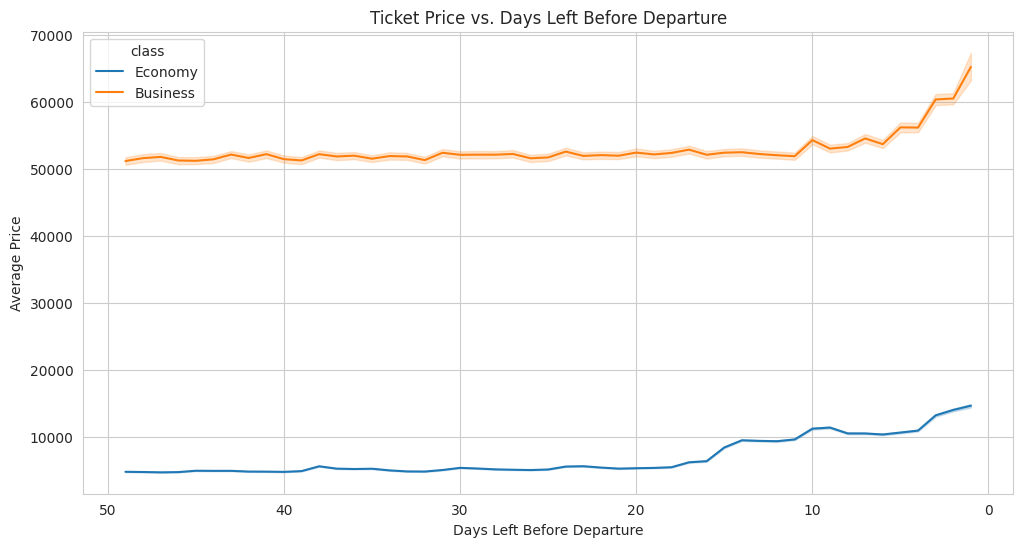

In [18]:
# 2. Analyze how 'days_left' influences ticket price
# We'll use Clean_Dataset.csv as it already contains the pre-calculated 'days_left' column for the whole dataset
clean_df = pd.read_csv('/content/dataset/Clean_Dataset.csv')

plt.figure(figsize=(12, 6))
sns.lineplot(data=clean_df, x='days_left', y='price', hue='class')
plt.title('Ticket Price vs. Days Left Before Departure')
plt.xlabel('Days Left Before Departure')
plt.ylabel('Average Price')
plt.gca().invert_xaxis() # Invert to show 'approaching departure' from left to right
plt.show()

### Summary of Analysis Results:

1. **Highest Average Price**: **Vistara** has the highest average ticket price (~30,396 INR), followed by Air India.
2. **Days Left Impact**: Prices generally increase significantly as the departure date approaches (days left decreases), especially within the last 15 days.
3. **Top 5 Routes**: The most expensive route on average is **Chennai to Bangalore**, followed by Kolkata to Chennai and Bangalore to Kolkata.
4. **Stops vs. Price**: For both classes, **1-stop flights** are generally more expensive than non-stop flights, likely due to longer total distances and travel times, though Business class shows a much sharper increase.
5. **Economy vs. Business**: Business class tickets are significantly more expensive with a much wider price range compared to Economy tickets, which are clustered at the lower end of the scale.